In [64]:
import os 
from dotenv import load_dotenv
load_dotenv()
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

In [65]:
from langchain.agents import create_agent
from typing_extensions import TypedDict,Annotated

class BlogState(TypedDict, total=False):

    youtube_url: str
    raw_metadata: str
    cleaned_content: str
    summary: str
    blog_title: str
    blog_content: str


In [66]:
from langchain.chat_models import init_chat_model
model=init_chat_model('google_genai:gemini-2.5-flash')



In [67]:
from yt_dlp import YoutubeDL
from youtube_transcript_api import YouTubeTranscriptApi
from urllib.parse import urlparse, parse_qs

def extract_youtube_data(state: BlogState):
    """
    Takes YouTube URL and returns:
    - title
    - description
    - transcript
    """

    # -------- Extract Metadata --------

    with YoutubeDL({}) as ydl:
        info = ydl.extract_info(state['youtube_url'], download=False)

    title = info.get("title", "")
    description = info.get("description", "")

    # -------- Extract Video ID --------


    parsed_url = urlparse(state['youtube_url'])

    if parsed_url.hostname in ["www.youtube.com", "youtube.com"]:
        video_id = parse_qs(parsed_url.query).get("v", [None])[0]

    if parsed_url.hostname == "youtu.be":
        video_id = parsed_url.path[1:]

    if not video_id:
        return "Invalid YouTube URL"

    # -------- Get Transcript --------

    try:
        api = YouTubeTranscriptApi()

        transcript = api.fetch(video_id)

        transcript_text = " ".join([x.text for x in transcript])

    except Exception as e:

        transcript_text = f"Transcript not available: {str(e)}"

    # -------- Final Combined Output --------

    final_text = f"""
        TITLE:
        {title}

        DESCRIPTION:
        {description}

        TRANSCRIPT:
        {transcript_text}
        """

    return {
        "raw_metadata": final_text
    }

In [68]:
def clean_metadata(state: BlogState):

    raw_data = state["raw_metadata"]

    response = model.invoke(f"""
    Clean this YouTube metadata and transcript.
    
    Focus on:
    - main topic
    - important concepts
    - remove noise
    - prioritize title and transcript
    
    DATA:
    {raw_data}
    """)

    return {
        "cleaned_content": response.content
    }
    

In [69]:
def generate_blog(state: BlogState):

    title = state["blog_title"]

    summary = state["summary"]

    response = model.invoke(f"""
        Write detailed professional blog.

        TITLE:
        {title}

        CONTENT:
        {summary}
        """)

    return {
        "blog_content": response.content
    }

In [70]:
def generate_blog_title(state: BlogState):

    summary = state["summary"]

    response = model.invoke(f"""
    Generate SEO friendly blog title.

    {summary}
    """)

    return {
        "blog_title": response.content
    }

In [71]:
def summarize_content(state: BlogState):

    content = state["cleaned_content"]

    response = model.invoke(f"""
    Summarize this content into key points.

    {content}
    """)

    return {
        "summary": response.content
    }

In [72]:
import json

def generate_blog_post(state):

    summary = state["summary"]

    response = model.invoke(f"""
        Return ONLY valid JSON.

        {{
        "title":"...",
        "content":"..."
        }}

        Write a complete blog article.

        Requirements:
        - 800-1200 words
        - Introduction
        - Main discussion
        - Conclusion
        - Professional tone
        - Paragraphs instead of bullet points

        CONTENT:
        {summary}
        """)

    content = response.content.strip()

    # Remove markdown fences if Gemini adds them
    if content.startswith("```json"):
        content = content.replace("```json", "").replace("```", "").strip()

    data = json.loads(content)

    return {
        "blog_title": data["title"],
        "blog_content": data["content"]
    }

In [73]:
from langgraph.graph import START, END,StateGraph

builder = StateGraph(BlogState)

builder.add_node("extract", extract_youtube_data)
builder.add_node("clean", clean_metadata)
builder.add_node("summarize", summarize_content)
builder.add_node("generate_post", generate_blog_post)

builder.add_edge(START, "extract")
builder.add_edge("extract", "clean")
builder.add_edge("clean", "summarize")
builder.add_edge("summarize", "generate_post")
builder.add_edge("generate_post", END)

graph = builder.compile()

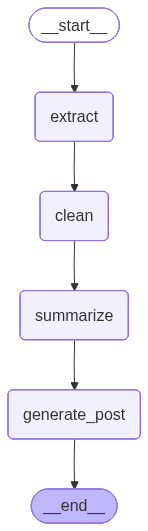

In [74]:
graph

In [75]:
result = graph.invoke({
    "youtube_url": "https://youtu.be/7nGN11DW-b0?si=b75ldsljj3hTvLPY"
})

[youtube] Extracting URL: https://youtu.be/7nGN11DW-b0?si=b75ldsljj3hTvLPY
[youtube] 7nGN11DW-b0: Downloading webpage


[youtube] 7nGN11DW-b0: Downloading android vr player API JSON


In [76]:
print("Title : ",result["blog_title"])
print()
print("Content : ",result["blog_content"])

Title :  UFOs: Extraterrestrial Enigma or Earthly Secrecy?

Content :  For decades, the concept of Unidentified Flying Objects (UFOs) has captivated the human imagination, sparking debates, fueling conspiracy theories, and inspiring countless works of fiction. What began as fleeting lights in the sky and blurry photographs has evolved into a complex narrative, now intertwined with official government investigations and declassified documents. The core question at the heart of this enduring mystery remains: Are these unexplained phenomena evidence of advanced extraterrestrial civilizations visiting Earth, or do they represent highly classified human technology, perhaps even from terrestrial adversaries? This article delves into the various facets of the UFO phenomenon, examining historical and contemporary sightings, scrutinizing government disclosures, and exploring the most plausible explanations that ground these extraordinary claims in a more earthly reality.

The public's fascinati